In [1]:
from examples import construct_sphere as c
from utils.plotting import plot_polar_deg, plot_polar_rad

Reconstruct latitudes

In [2]:
construction_methods = [c.construct_degs_from_linspace,
 c.construct_rad_from_linspace,
  c.construct_degs_transposed,
  c.construct_degs_scaled,] # c.construct_degs_from_sh_grid

reconstruction_methods = [c.reconstruct_function_dh, c.reconstruct_function_lsq, c.reconstruct_function_shgrid]

plot_construction = [plot_polar_deg, plot_polar_rad, plot_polar_deg, plot_polar_deg]

shape (50, 50)
2.5366568963229525


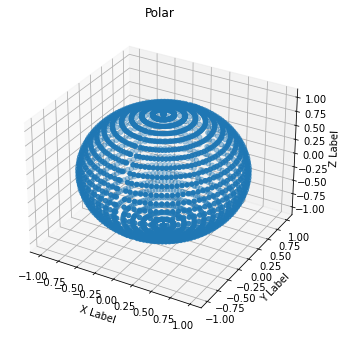

0.9086151931519311


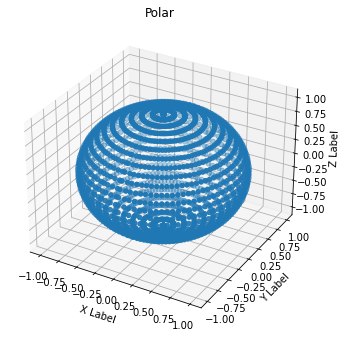

2.5366568963229383


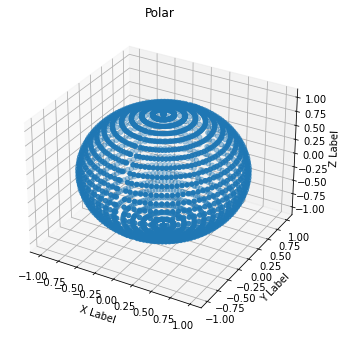

shape (50, 50)
0.088546029668513


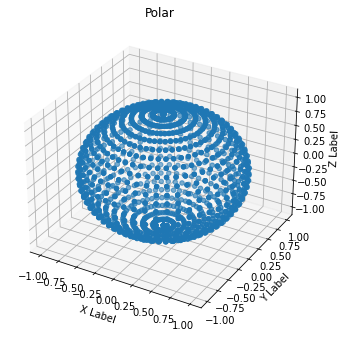

1.7763568394002505e-15


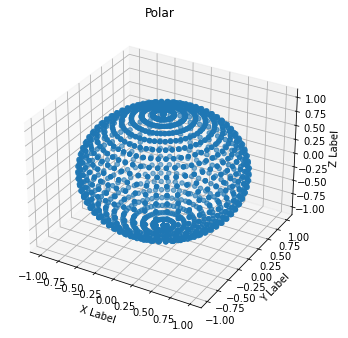

3.032339556932966


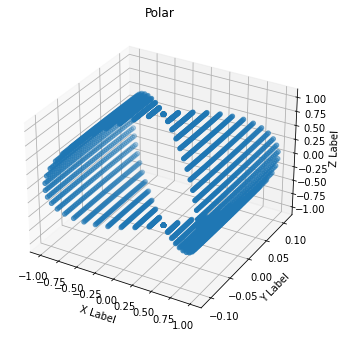

shape (50, 50)
2.5366568963229525


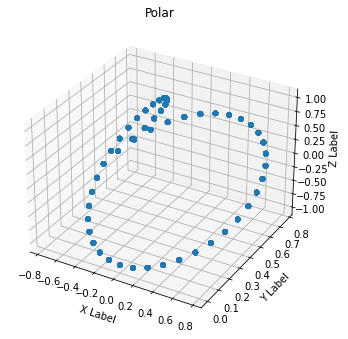

0.00047912597656818434


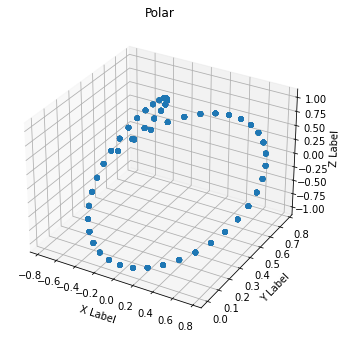

2.5366568963229383


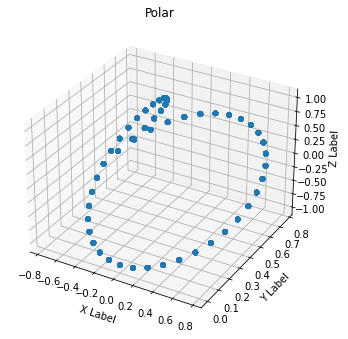

shape (50, 50)
0.014092538312905023


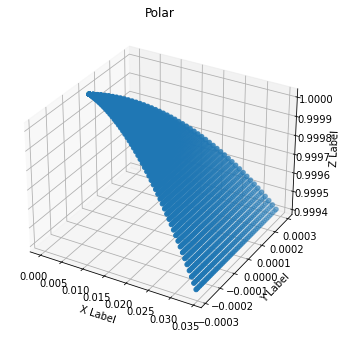

3.885780586188048e-16


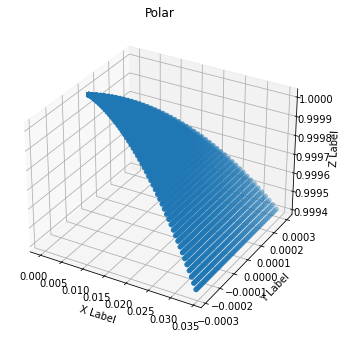

0.4972364331316181


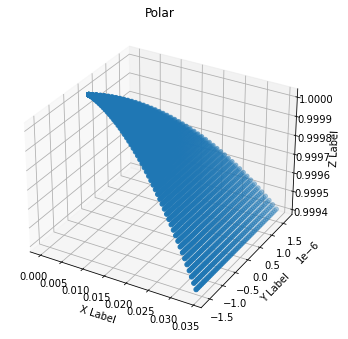

In [3]:
for i, construct in enumerate(construction_methods):
    r, lats, lons = construct()
    print("shape", lats.shape)
    for reconstruct in reconstruction_methods:
        lats_recon = reconstruct(lats, lats=lats, lons=lons)
        c.error(lats, lats_recon)
        plot_construction[i](r, lats_recon, lons)
        

Reconstruct Longitudes

shape (50, 50)
176.40000000000106


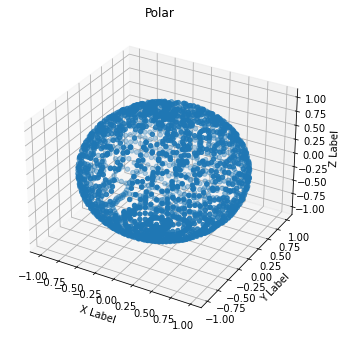

176.40000000000003


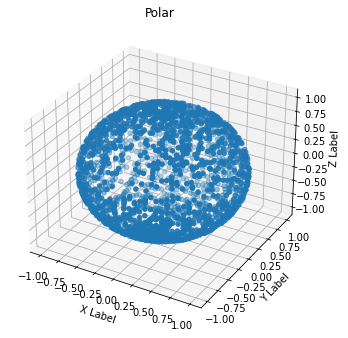

176.400000000001


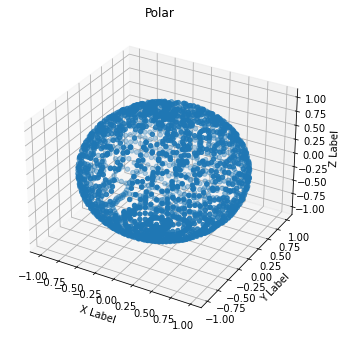

shape (50, 50)
3.078760800518017


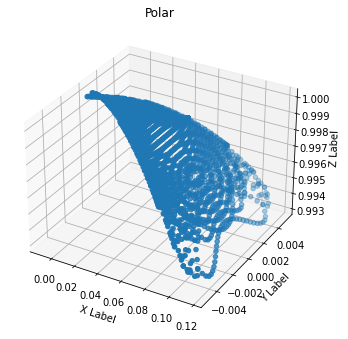

7.549516567451064e-15


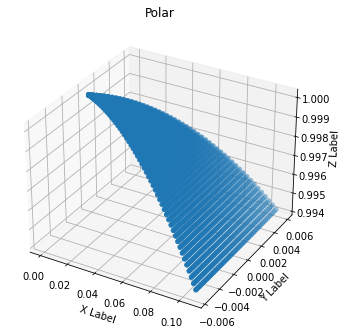

6.352759666256191


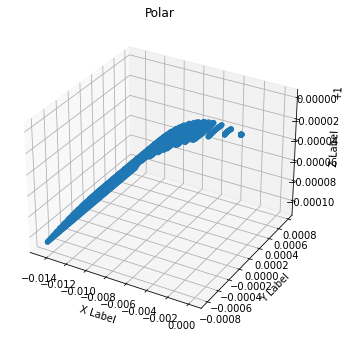

shape (50, 50)
5.073313792647066


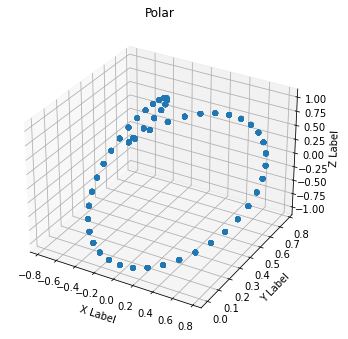

0.0017822265625113687


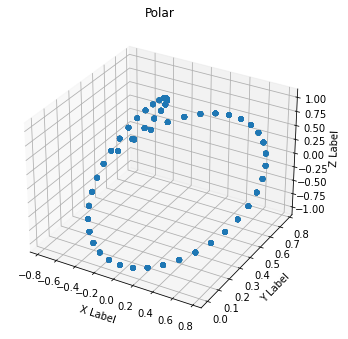

5.07331379264707


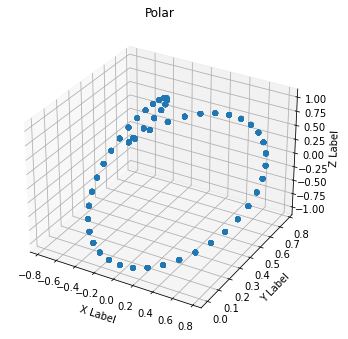

shape (50, 50)
0.9800000000000058


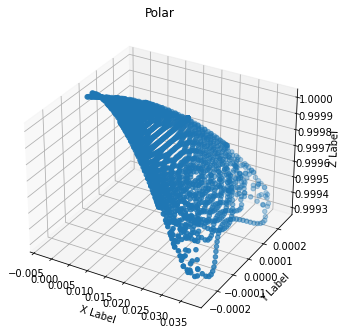

9.992007221626409e-16


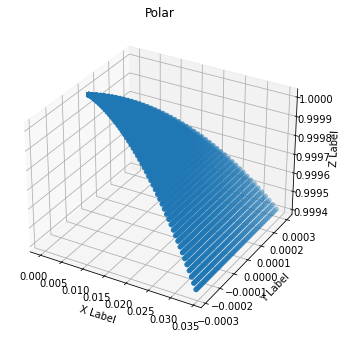

2.1997303872356024


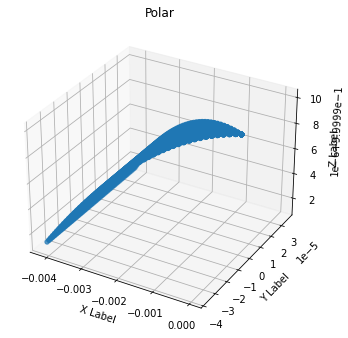

In [7]:
for construct in construction_methods:
    r, lats, lons = construct()
    print("shape", lons.shape)
    for reconstruct in reconstruction_methods:
        lons_recon = reconstruct(lons, lats=lats, lons=lons)
        c.error(lons, lons_recon)
        plot_construction[i](r, lats, lons_recon)

Try with scaled points on scaled grid

In [5]:
import pyshtools as pysh 

r, scaled_lats, scaled_lons = c.construct_rad_from_linspace()
lats_subgrid, lons_subgrid = scaled_lats[::2, ::2], scaled_lons[::2, ::2]
_, lats_expanded_grid, lons_expanded_grid = c.construct_rad_from_linspace(grid_size=100)

coeffs = pysh.expand.SHExpandLSQ(d=scaled_lons, lat=scaled_lats, lon=scaled_lons, lmax=scaled_lons.shape[0]/2-1)[0]
f_recon = pysh.expand.MakeGridPoint(coeffs, lat=lats_expanded_grid, lon=lons_expanded_grid)

c.error(lons_expanded_grid, f_recon)

7.549516567451064e-15


array([[7.54951657e-15, 3.63598041e-15, 2.38697950e-15, ...,
        0.00000000e+00, 0.00000000e+00, 1.77635684e-15],
       [6.21724894e-15, 3.63598041e-15, 3.27515792e-15, ...,
        8.88178420e-16, 0.00000000e+00, 0.00000000e+00],
       [5.32907052e-15, 3.19189120e-15, 1.94289029e-15, ...,
        8.88178420e-16, 1.77635684e-15, 8.88178420e-16],
       ...,
       [1.77635684e-15, 1.85962357e-15, 6.10622664e-16, ...,
        2.66453526e-15, 1.77635684e-15, 3.55271368e-15],
       [8.88178420e-16, 9.71445147e-16, 1.66533454e-16, ...,
        1.77635684e-15, 1.77635684e-15, 3.55271368e-15],
       [1.77635684e-15, 9.71445147e-16, 2.77555756e-16, ...,
        2.66453526e-15, 1.77635684e-15, 1.77635684e-15]])

Try adding noise

In [6]:
noisy_coeffs = c.add_noise_to_coefficients(coeffs, standard_deviation=0.0001)
noisy_f = pysh.expand.MakeGridPoint(noisy_coeffs, lat=scaled_lats, lon=scaled_lons)
c.error(scaled_lons, noisy_f)


0.005336999992620051


array([[0.00051862, 0.00047458, 0.00042867, ..., 0.00352242, 0.00363827,
        0.00375408],
       [0.00047065, 0.00042446, 0.00037644, ..., 0.00361586, 0.00373169,
        0.00384745],
       [0.0004204 , 0.00037208, 0.00032197, ..., 0.00370865, 0.00382436,
        0.00394   ],
       ...,
       [0.00174976, 0.00182491, 0.00189942, ..., 0.00418131, 0.00421207,
        0.00424248],
       [0.001753  , 0.00182691, 0.00190015, ..., 0.00407836, 0.00410612,
        0.00413354],
       [0.00175339, 0.001826  , 0.0018979 , ..., 0.00397113, 0.00399588,
        0.00402029]])